In [90]:
import numpy as np
import cv2
import smtplib
from email.message import EmailMessage
from datetime import datetime
from pathlib import Path
import mimetypes
import os
import matplotlib.pyplot as plt 
import numpy as np
import os
import cv2
import torch
import matplotlib.pyplot as plt 
from torchvision import models, transforms
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import models, transforms
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pickle
import torchvision.transforms.functional as TF
from time import time


CURRENT_DIR = (os.getcwd())
BASE_DIR = os.path.abspath(os.path.join(CURRENT_DIR, ".."))

def load_model(transformation: str = None): 
    model = models.resnet18(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes
    filename = f"resnet18_pitting_not_simplified_{transformation}.pth" if transformation else "resnet18_pitting_not_simplified.pth"
    load_path = os.path.join(BASE_DIR, "models", filename)
    model.load_state_dict(torch.load(load_path))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) 
    model.eval()
    return model 




In [91]:
model = load_model("light")

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [92]:
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



In [93]:
image = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/06. SS_2025/Pitting_Detection/dataset/KGT_noDefect/N (69).png"
image = Image.open(image).convert("RGB")
image_tensor = test_transform(image)

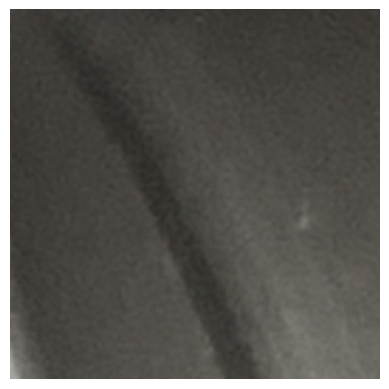

In [94]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_image = image_tensor * std[:, None, None] + mean[:, None, None]


image_np = unnormalized_image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.axis("off")
plt.show()


In [ ]:
gradients = []
    
if image_tensor.shape != (1, 3, 224, 224):
    if image_tensor.shape == (3, 224, 224):
            image_tensor_batched = image_tensor.unsqueeze(0)
    else:
        raise ValueError(f"Unerwartete Bildgröße: {image_tensor.shape}")
else:
    image_tensor_batched = image_tensor

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_image = image_tensor * std[:, None, None] + mean[:, None, None]

image_np = unnormalized_image.permute(1, 2, 0).numpy()


def save_gradient(grad):
    gradients.append(grad)

#Forward hook for activations
activations = []

def forward_hook(module, input, output):
    activations.append(output)
    output.register_hook(save_gradient)

# Register the hook to the last conv layer of ResNet18
target_layer = model.layer4
hook = target_layer.register_forward_hook(forward_hook)

# Forward pass
output = model(image_tensor_batched)
pred_class = output.argmax(dim=1).item()

#Backward pass for Grad-CAM 
model.zero_grad()
output[0, pred_class].backward()



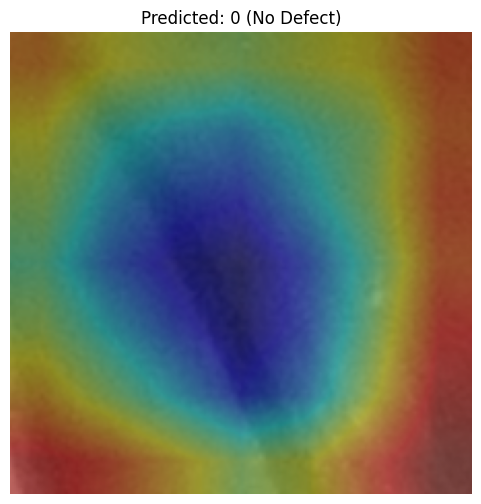

In [95]:
def plot_heatmap(model, img_tensor):

    gradients = []
    
    if img_tensor.shape != (1, 3, 224, 224):
        if img_tensor.shape == (3, 224, 224):
                image_tensor_batched = img_tensor.unsqueeze(0)
        else:
            raise ValueError(f"Unerwartete Bildgröße: {img_tensor.shape}")
    else:
        image_tensor_batched = img_tensor

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    unnormalized_image = img_tensor * std[:, None, None] + mean[:, None, None]

    image_np = unnormalized_image.permute(1, 2, 0).numpy()


    def save_gradient(grad):
        gradients.append(grad)

    #Forward hook for activations
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    # Register the hook to the last conv layer of ResNet18
    target_layer = model.layer4
    hook = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    output = model(image_tensor_batched)
    pred_class = output.argmax(dim=1).item()

    #Backward pass for Grad-CAM 
    model.zero_grad()
    output[0, pred_class].backward()

    # Get activations and gradients 
    grads_val = gradients[0][0].cpu().detach().numpy()  # (C, H, W)
    acts_val = activations[0][0].cpu().detach().numpy()  # (C, H, W)

    # Compute the weights and CAM
    weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
    cam = np.zeros(acts_val.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts_val[i, :, :]

    #Normalize and resize the CAM 
    cam = np.maximum(cam, 0)  # ReLU
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cv2.resize(cam, (224, 224))

    # Overlay the heatmap on the image 
    #img_np = np.array(image.resize((224, 224)))  # Original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    inverted_heatmap = cv2.bitwise_not(heatmap)
    image_uint8 = (image_np * 255).astype(np.uint8)
    overlay = heatmap * 0.4 + image_uint8 * 0.6
    overlay = np.uint8(overlay)

    # Show the result 
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title(f"Predicted: {pred_class} ({'Pitting' if pred_class == 1 else 'No Defect'})")
    plt.axis('off')
    plt.show()

    # Cleanup
    hook.remove()

plot_heatmap(model, image_tensor)